File saved: Figure_1b_Reproduced_Final_v3.pdf


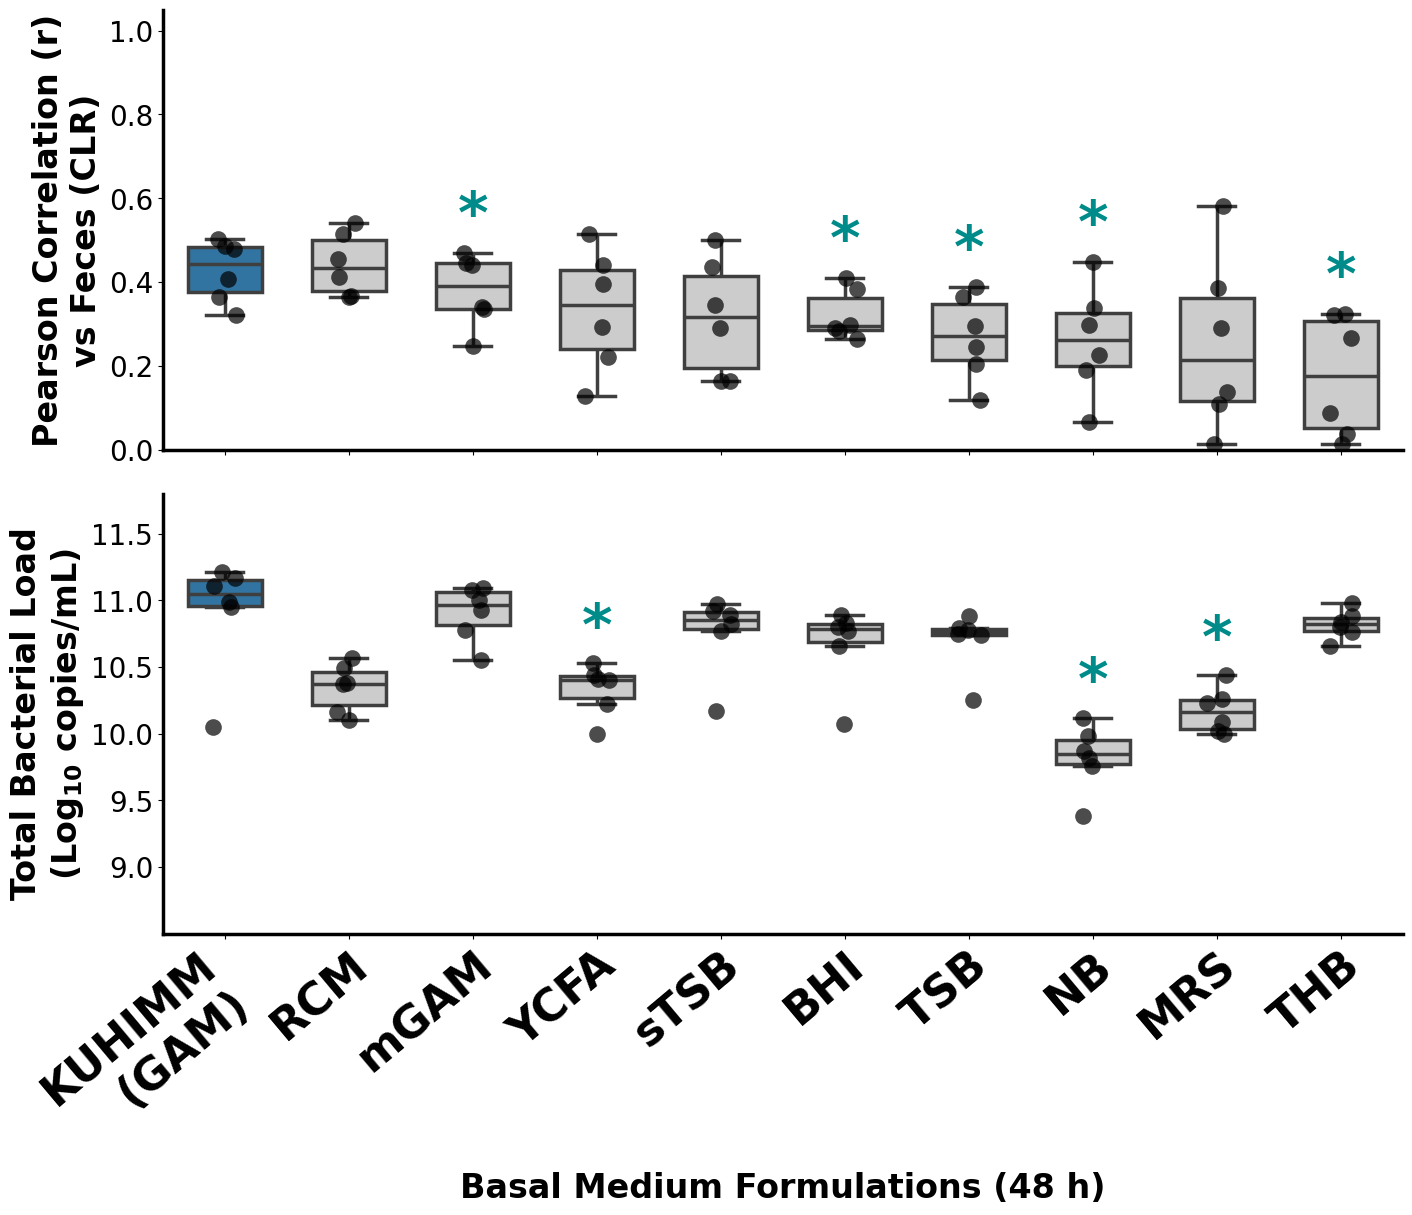

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms
from scipy.stats import pearsonr, wilcoxon
from scipy.stats.mstats import gmean
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Notebook Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# =============================================================================
# 1. Load Data
# =============================================================================
file_16s = '(1b)_Medium_16S_Genus_level.csv'
file_total = '1b_Total_Bacteria.csv'

df_1b = pd.read_csv(file_16s)
df_tot_raw = pd.read_csv(file_total)

# --- Process Top Panel Data (Stability) ---
bac_cols = [c for c in df_1b.columns if c.startswith('d__Bacteria')]
df_1b['Time'] = df_1b['Subject'].apply(lambda x: '0h' if 'FEC' in x else ('24h' if '24h' in x else '48h'))
clusters = df_1b['Cluster'].unique()
media_list = [m for m in df_1b['Feature'].unique() if m != 'FEC']

def clr_transform(x):
    x = np.array(x, dtype=float)
    if (x == 0).any():
        pseudo = x[x > 0].min() * 0.5 if (x > 0).any() else 1e-9
        x = np.where(x == 0, pseudo, x)
    return np.log(x / gmean(x))

results_1b = []
for cl in clusters:
    df_cl = df_1b[df_1b['Cluster'] == cl]
    fec_row = df_cl[df_cl['Time'] == '0h']
    if len(fec_row) >= 1:
        fec_vals = fec_row[bac_cols].values[0].astype(float)
        for feat in media_list:
            feat_row = df_cl[(df_cl['Time'] == '48h') & (df_cl['Feature'] == feat)]
            if len(feat_row) >= 1:
                feat_vals = feat_row[bac_cols].values[0].astype(float)
                mask = (fec_vals > 0) | (feat_vals > 0)
                if np.sum(mask) > 3:
                    fec_filt, feat_filt = fec_vals[mask], feat_vals[mask]
                    pseudo_fec = fec_filt[fec_filt > 0].min() * 0.5 if len(fec_filt[fec_filt > 0]) > 0 else 1e-6
                    pseudo_feat = feat_filt[feat_filt > 0].min() * 0.5 if len(feat_filt[feat_filt > 0]) > 0 else 1e-6
                    fec_imputed = np.where(fec_filt == 0, pseudo_fec, fec_filt)
                    feat_imputed = np.where(feat_filt == 0, pseudo_feat, feat_filt)

                    corr, _ = pearsonr(clr_transform(fec_imputed), clr_transform(feat_imputed))
                    display_name = 'KUHIMM\n(GAM)' if feat == 'GAM' else feat
                    results_1b.append({'Donor': cl, 'Condition': display_name, 'Pearson_CLR': corr})

df_res = pd.DataFrame(results_1b)
order = df_res.groupby('Condition')['Pearson_CLR'].median().sort_values(ascending=False).index.tolist()

# --- Process Bottom Panel Data (Total Load) ---
col_mapping = {
    'KUHIMM': 'KUHIMM\n(GAM)', 'modified GAM': 'mGAM', 'RCM': 'RCM', 'BHI': 'BHI',
    'YCFA': 'YCFA', 'TSB': 'TSB', 'supplemented TSB': 'sTSB', 'Todd-Hewitt Broth': 'THB',
    'MRS': 'MRS', 'Nutrient Broth': 'NB'
}
df_tot = df_tot_raw.rename(columns=col_mapping)
df_melt_bot = df_tot.melt(id_vars=df_tot.columns[0], value_vars=order, var_name='Condition', value_name='Total_Bacteria')

# =============================================================================
# 2. Visualization
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True, gridspec_kw={'hspace': 0.1})
palette = {cond: '#1f77b4' if cond == 'KUHIMM\n(GAM)' else '#CCCCCC' for cond in order}
baseline_name = 'KUHIMM\n(GAM)'

# Highlight Color for Asterisks (Dark Turquoise)
star_color = '#008B8B'

# --- Top Panel ---
ax_top = axes[0]
sns.boxplot(x='Condition', y='Pearson_CLR', data=df_res, order=order, palette=palette,
            width=0.6, ax=ax_top, showfliers=False, linewidth=2.5)
sns.stripplot(x='Condition', y='Pearson_CLR', data=df_res, order=order, color='black', alpha=0.7, size=12, jitter=True, ax=ax_top)

ax_top.set_ylabel("Pearson Correlation (r)\nvs Feces (CLR)", fontsize=24, fontweight='bold')
ax_top.set_ylim(0.0, 1.05)
ax_top.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax_top.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=20, fontweight='normal')

# Stats (Top)
for i, cond in enumerate(order):
    if cond == baseline_name: continue
    y_base = df_res[df_res['Condition'] == baseline_name]['Pearson_CLR'].dropna().values
    y_comp = df_res[df_res['Condition'] == cond]['Pearson_CLR'].dropna().values
    min_len = min(len(y_base), len(y_comp))
    if min_len >= 3:
        _, p = wilcoxon(y_base[:min_len], y_comp[:min_len])
        if p < 0.05:
            r_max = df_res[df_res['Condition'] == cond]['Pearson_CLR'].max()
            ax_top.text(i, r_max + 0.02, '*', ha='center', va='bottom', color=star_color, fontsize=42, fontweight='bold')

# --- Bottom Panel ---
ax_bot = axes[1]
sns.boxplot(x='Condition', y='Total_Bacteria', data=df_melt_bot, order=order, palette=palette,
            width=0.6, ax=ax_bot, showfliers=False, linewidth=2.5)
sns.stripplot(x='Condition', y='Total_Bacteria', data=df_melt_bot, order=order, color='black', alpha=0.7, size=12, jitter=True, ax=ax_bot)

ax_bot.set_ylabel("Total Bacterial Load\n(Log$_{10}$ copies/mL)", fontsize=24, fontweight='bold')
ax_bot.set_xlabel("Basal Medium Formulations (48 h)", fontsize=24, fontweight='bold', labelpad=15)
ax_bot.set_ylim(8.5, 11.8)
ax_bot.set_yticks([9.0, 9.5, 10.0, 10.5, 11.0, 11.5])
ax_bot.set_yticklabels(['9.0', '9.5', '10.0', '10.5', '11.0', '11.5'], fontsize=20, fontweight='normal')

# Stats (Bottom)
for i, cond in enumerate(order):
    if cond == baseline_name: continue
    y_vals_base = df_tot[baseline_name].dropna().values
    y_vals_comp = df_tot[cond].dropna().values
    min_len = min(len(y_vals_base), len(y_vals_comp))
    if min_len >= 3:
        _, p = wilcoxon(y_vals_base[:min_len], y_vals_comp[:min_len])
        if p < 0.05:
            m_max = df_melt_bot[df_melt_bot['Condition'] == cond]['Total_Bacteria'].max()
            ax_bot.text(i, m_max + 0.05, '*', ha='center', va='bottom', color=star_color, fontsize=42, fontweight='bold')

# --- X-axis Label Offset Logic (Bulletproof Transform Method) ---
ax_bot.set_xticklabels(order, rotation=40, ha='right', rotation_mode='anchor', fontsize=32, fontweight='bold')

# Shift KUHIMM label precisely to the left by 20 points
dx_points = -20 / 72.0  # Convert points to inches for the transformation
dy_points = 0
offset = mtransforms.ScaledTranslation(dx_points, dy_points, fig.dpi_scale_trans)

for label in ax_bot.get_xticklabels():
    if "KUHIMM" in label.get_text():
        label.set_transform(label.get_transform() + offset)

sns.despine()
plt.tight_layout()

# Save output
output_file = "Figure_1b_Reproduced_Final.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight')
print(f"File saved: {output_file}")